# SHL Hiring Assessment 2026 — Grammar Scoring Engine for Spoken English

**Task.** Predict a continuous grammar score (MOS Likert, 1–5 rubric) from 45–60 s audio clips.
**Data.** 769 labelled training clips, 216 test clips (16 kHz mono WAV).
**Metrics.** RMSE and Pearson correlation, reported from 5-fold cross-validation (random folds and speaker-grouped folds) and on the full training set.

---

## Report

### 1. Approach in one paragraph
Grammar is judged from *what* a speaker says and *how* they build sentences, so the pipeline listens to each clip with a strong
pretrained speech-recognition model (NVIDIA **Parakeet-TDT-0.6B-v2**). From that one model I take two things:
(a) the **transcript** (with word timestamps), from which I compute interpretable linguistic and fluency features, and
(b) the model's **internal acoustic-linguistic representation**: the hidden states of five of its 24 encoder layers
(layers 4, 8, 12, 16, 20), each averaged over time, which summarise the whole recording as a 5 × 1024-number vector. Simple regressors (Ridge, SVR) are trained on these, and their
out-of-fold predictions are combined with a non-negative linear blend.

### 2. Key data finding: a corrupted batch of training labels
* 37 training clips are labelled **0**, which is outside the 1–5 rubric.
* All 37 have IDs `audio_5037`–`audio_5073`, are saved with a **different WAV header layout** from every other file, and
  **none of the 216 test files share that format**.
* One of them, `audio_5044` (label 0), is the **same recording** as `audio_743` (label 4.0) — its transcript is identical.

These rows are label noise from a separate batch, so they are **excluded from training**, and predictions are clipped to 1–5.
On identical validation folds (clean clips only), removing them lowers the error for the transcript-based models
(RMSE 0.774 → 0.729) and for the final ensemble (0.509 → 0.498) — see the ablation in Section 8.1.

### 2b. Key evaluation finding: the same speakers recur in the training set
Speaker embeddings show that 65% of training clips have another training clip with a near-identical voice (cosine > 0.95),
but only 1 of the 216 test clips does. Random K-fold therefore lets the model partly *recognise voices*, which flatters the score.
Keeping each speaker cluster inside one fold (speaker-grouped CV) gives the honest estimate for new speakers — see Section 8.3.

### 3. Pipeline
| Stage | What happens |
|---|---|
| Preprocessing | Load WAV → mono float32 at 16 kHz (all files already 16 kHz). NeMo-style log-mel: pre-emphasis 0.97, 25 ms Hann window, 10 ms hop, 128 mel bins, per-utterance normalisation. |
| ASR | Parakeet-TDT-0.6B-v2 (int8 ONNX via `sherpa-onnx`, CPU). Keeps learner errors largely intact (e.g. *"there was many people"*), unlike ASR models that "clean up" speech. |
| Embeddings | Hidden states of encoder layers 4, 8, 12, 16 and 20 (1024-d per 80 ms frame) → mean over time → 5 × 1024 = 5120-d vector per clip. Middle/upper layers mix acoustic and linguistic information; combining several layers beats using only the final output (Ridge: CV RMSE 0.59 → 0.52). |
| Linguistic features (52) | Fluency (speech rate, pauses), length, vocabulary (MATTR, word frequency), syntax from a spaCy parse (clauses, parse depth, POS mix, fragments), and rule-based grammar-error counts (subject–verb agreement, determiner–noun number, a/an, bare past after *did/to*…). |
| Models | Ridge (layer embeddings), SVR (layer embeddings, PCA-256), SVR (linguistic features), Ridge on character n-gram TF-IDF of the transcript, Ridge (embeddings + features). |
| Ensemble | Non-negative linear regression on out-of-fold predictions (5-fold CV), predictions clipped to [1, 5]. |

### 4. Results
See **Section 8** for the full results and plots, and **Section 8.1** for the ablation (all numbers are computed live in this notebook).

| Model (5-fold CV on 732 clean clips) | CV RMSE | CV Pearson |
|---|---|---|
| Ridge, layer embeddings | 0.515 | 0.860 |
| SVR, layer embeddings | 0.503 | 0.867 |
| SVR, linguistic features | 0.830 | 0.577 |
| Ridge, char n-gram TF-IDF | 0.762 | 0.661 |
| Ridge, embeddings + features | 0.515 | 0.860 |
| **Ensemble (final)** | **0.498** | **0.871** |

**Training-set RMSE of the final ensemble (fitted on all 732 clean training clips): 0.156** (Pearson 0.990).
Predict-the-mean baseline RMSE: 1.014.

**Honest estimate for new speakers (speaker-grouped 5-fold CV): RMSE 0.542, Pearson 0.845** (Section 8.3).
Two things make the test set harder than random-fold CV suggests: test speakers are new (Section 8.3), and 69% of test clips are
the shorter ~45-second recordings, on which the model is less accurate (Section 8.2). **Expected test RMSE ≈ 0.55.**

How each decision moved the error (ablation, Section 8.1 — every row uses the **same validation folds on the 732 clean clips**, so the numbers are directly comparable):

| Step | CV RMSE |
|---|---|
| Transcript-based models only (linguistic features + TF-IDF), trained **with** the label-0 batch | 0.774 |
| Same, label-0 batch **removed** | 0.729 |
| + final-layer speech-model embedding | 0.582 |
| + embeddings from five encoder layers (final pipeline) | **0.498** |
| Final pipeline, but trained **with** the label-0 batch | 0.509 |

### 5. Why this design
* **Small data (732 clean samples)** → no end-to-end fine-tuning; instead, strong frozen pretrained representations + regularised linear/kernel models, which are stable and fast to validate.
* **Interpretability** → the handcrafted features show *which* properties of speech relate to grammar scores (Section 9), while the embedding models supply accuracy.
* **Honest evaluation** → every number is out-of-fold; the blend weights are learned on out-of-fold predictions only; and the final estimate uses speaker-grouped folds so that no voice appears in both training and validation.

## 0. Setup
Works on Kaggle (CPU is enough; Internet must be **On** to fetch the speech model from GitHub) or locally.

In [1]:
# Install dependencies first, before anything is imported (already-installed packages are skipped).
import subprocess, sys
_pip = subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "sherpa-onnx", "onnx", "onnxruntime", "spacy>=3.8,<3.9", "wordfreq", "librosa", "soundfile",
                "https://github.com/explosion/spacy-models/releases/download/en_core_web_md-3.8.0/en_core_web_md-3.8.0-py3-none-any.whl"],
               capture_output=True, text=True, check=False)
print("dependencies ready" if _pip.returncode == 0 else _pip.stderr[-2000:])

dependencies ready


In [2]:
import os, re, glob, json, struct, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import pearsonr
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
SEED = 42
np.random.seed(SEED)

# ---- paths: auto-detect the competition folder (Kaggle or local) ----
def find_data_dir():
    for root in ["/kaggle/input", ".", "..", os.path.expanduser("~/Downloads")]:
        for p in glob.glob(f"{root}/**/train.csv", recursive=True):
            d = os.path.dirname(p)
            if os.path.isdir(f"{d}/train") and os.path.isdir(f"{d}/test"):
                return d
    raise FileNotFoundError("Could not find a folder with train.csv, train/ and test/")
DATA = os.environ.get("DATA_DIR") or find_data_dir()
WORK = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
def find_cache():
    # cached speech-model outputs: next to the notebook, in the working dir, or in an attached Kaggle dataset
    if os.environ.get("CACHE_DIR"):
        return os.environ["CACHE_DIR"]
    for root in [WORK, ".", "/kaggle/input"]:
        for p in glob.glob(f"{root}/**/emb_all.npz", recursive=True):
            if os.path.exists(os.path.join(os.path.dirname(p), "transcripts_all.jsonl")):
                return os.path.dirname(p)
    return WORK
CACHE = find_cache()
print("data:", DATA, "| work:", WORK, "| cache:", CACHE)

data: /mnt/user-data/uploads/Dataset_Final | work: . | cache: .


## 1. Load data

In [3]:
train = pd.read_csv(f"{DATA}/train.csv")
test = pd.read_csv(f"{DATA}/test.csv")
sample = pd.read_csv(f"{DATA}/sample_submission.csv")
print("train", train.shape, "| test", test.shape, "| sample_submission", sample.shape)
print("test files present on disk:", test.filename.isin(os.listdir(f"{DATA}/test")).sum(), "/", len(test))
print("sample_submission filenames that are real test files:", sample.filename.isin(test.filename).sum(), "/", len(sample))
train.head()

train (769, 2) | test (216, 2) | sample_submission (204, 2)
test files present on disk: 216 / 216
sample_submission filenames that are real test files: 25 / 204


,filename,label
0,audio_192.wav,3.0
1,audio_436.wav,3.0
2,audio_447.wav,3.5
3,audio_126.wav,2.0
4,audio_61.wav,2.0


> **Note:** `sample_submission.csv` lists mostly filenames that are *not* in the test set, so the submission is built from the 216 filenames in **`test.csv`**, using the sample only for its column format (`filename,label`).

## 2. Exploratory data analysis

sample rates: [16000] | channels: [1]


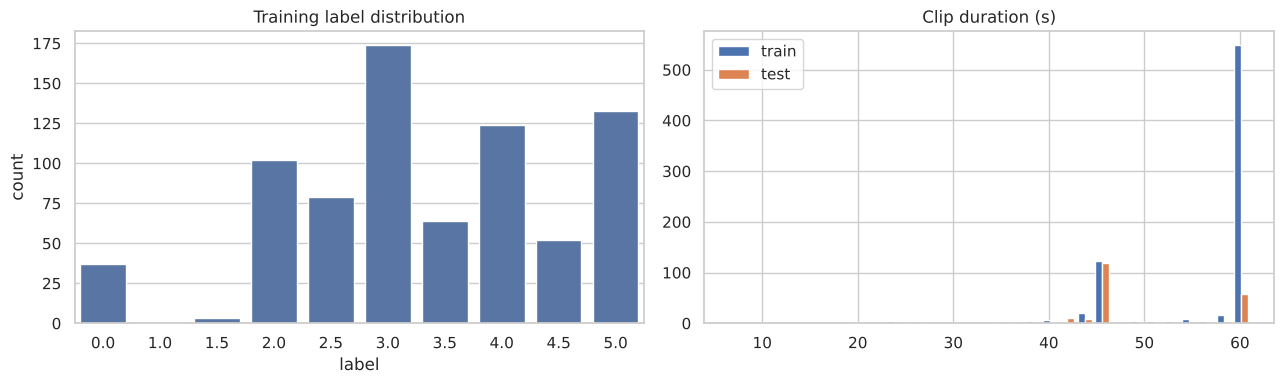

In [4]:
def wav_info(path):
    with open(path, "rb") as f:
        head = f.read(64)
    i = head.find(b"fmt ")
    ch, sr = struct.unpack("<HI", head[i + 10:i + 16])
    return {"sr": sr, "channels": ch, "data_at_36": head.find(b"data") == 36, "duration": (os.path.getsize(path) - 44) / (sr * 2 * ch)}

train = train.join(pd.DataFrame([wav_info(f"{DATA}/train/{f}") for f in train.filename]))
test = test.join(pd.DataFrame([wav_info(f"{DATA}/test/{f}") for f in test.filename]))
print("sample rates:", sorted(set(train.sr) | set(test.sr)), "| channels:", sorted(set(train.channels) | set(test.channels)))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(x=train.label, ax=ax[0], color="#4C72B0"); ax[0].set_title("Training label distribution")
ax[1].hist([train.duration, test.duration], bins=30, label=["train", "test"]); ax[1].legend(); ax[1].set_title("Clip duration (s)")
plt.tight_layout(); plt.show()

### 2.1 The label-0 clips are a separate, corrupted batch

In [5]:
train["file_id"] = train.filename.str.extract(r"(\d+)").astype(int)
print(pd.crosstab(train.label == 0, train.data_at_36, rownames=["label==0"], colnames=["standard 44-byte WAV header"]))
print("\nTest files with that header layout:", int(test.data_at_36.sum()), "of", len(test))
print("IDs of label-0 clips:", train.loc[train.label == 0, "file_id"].min(), "to", train.loc[train.label == 0, "file_id"].max())

standard 44-byte WAV header  False  True 
label==0                                 
False                          732      0
True                             0     37

Test files with that header layout: 0 of 216
IDs of label-0 clips: 5037 to 5073


## 3. Preprocessing, transcription and embeddings

For every clip (one pass, audio loaded once):
1. **Load** → mono float32, 16 kHz.
2. **Transcribe** with Parakeet-TDT-0.6B-v2 → text + per-token timestamps.
3. **Embed**: compute the NeMo log-mel spectrogram and run the same model's encoder, exposing the outputs of layers 4, 8, 12, 16, 20 → time-averaged 1024-d vector per layer.

This is the slow step (~1–2 s per clip on CPU), so results are cached to `transcripts_all.jsonl` and `emb_all.npz`.
If those files are present in `CACHE` they are loaded instead of recomputed.

In [6]:
import soundfile as sf, librosa

MODEL_DIR = f"{WORK}/sherpa-onnx-nemo-parakeet-tdt-0.6b-v2-int8"
MODEL_URL = "https://github.com/k2-fsa/sherpa-onnx/releases/download/asr-models/sherpa-onnx-nemo-parakeet-tdt-0.6b-v2-int8.tar.bz2"
SR = 16000
LAYERS = [4, 8, 12, 16, 20]          # encoder layers whose time-averaged outputs form the embedding

def load_audio(path):
    a, sr = sf.read(path, dtype="float32", always_2d=True)
    a = a.mean(1)                                   # mono
    if sr != SR:
        a = librosa.resample(a, orig_sr=sr, target_sr=SR)
    return a

MEL = librosa.filters.mel(sr=SR, n_fft=512, n_mels=128, fmin=0, fmax=SR // 2, norm="slaney")
WIN = np.hanning(401)[:-1].astype(np.float32)
def log_mel(a):
    # NeMo AudioToMelSpectrogramPreprocessor: pre-emphasis, 25 ms Hann / 10 ms hop, 128 mel, log, per-feature norm
    a = np.append(a[0], a[1:] - 0.97 * a[:-1])
    S = np.abs(librosa.stft(a, n_fft=512, hop_length=160, win_length=400, window=WIN, center=True, pad_mode="constant")) ** 2
    M = np.log(MEL @ S + 2 ** -24)
    return ((M - M.mean(1, keepdims=True)) / (M.std(1, keepdims=True) + 1e-5)).astype(np.float32)

def run_speech_models(splits):
    import sherpa_onnx, onnxruntime as ort
    if not os.path.isdir(MODEL_DIR):
        subprocess.run(f"cd {WORK} && curl -sSL {MODEL_URL} | tar xj", shell=True, check=True)
    threads = os.cpu_count() or 4
    asr = sherpa_onnx.OfflineRecognizer.from_transducer(
        encoder=f"{MODEL_DIR}/encoder.int8.onnx", decoder=f"{MODEL_DIR}/decoder.int8.onnx",
        joiner=f"{MODEL_DIR}/joiner.int8.onnx", tokens=f"{MODEL_DIR}/tokens.txt",
        model_type="nemo_transducer", num_threads=threads)
    # expose intermediate encoder layers as extra ONNX outputs (graph edit, no retraining)
    multi = f"{WORK}/encoder_multi_layer.onnx"
    if not os.path.exists(multi):
        import onnx
        m = onnx.load(f"{MODEL_DIR}/encoder.int8.onnx")
        for L in LAYERS:
            m.graph.output.append(onnx.helper.make_tensor_value_info(
                f"/layers.{L}/norm_out/LayerNormalization_output_0", onnx.TensorProto.FLOAT, None))
        onnx.save(m, multi)
    so = ort.SessionOptions(); so.intra_op_num_threads = threads
    enc = ort.InferenceSession(multi, so)
    rows, embs, finals = [], {s: [] for s in splits}, {s: [] for s in splits}
    for split, files in splits.items():
        for i, fn in enumerate(files):
            a = load_audio(f"{DATA}/{split}/{fn}")
            st = asr.create_stream(); st.accept_waveform(SR, a); asr.decode_stream(st); r = st.result
            rows.append({"split": split, "filename": fn, "duration": len(a) / SR, "text": r.text.strip(),
                         "tokens": list(r.tokens), "timestamps": [round(t, 3) for t in r.timestamps]})
            M = log_mel(a)[None]
            out = enc.run(None, {"audio_signal": M, "length": np.array([M.shape[2]], dtype=np.int64)})
            n = int(out[1][0])                                   # valid frames after 8x subsampling
            h = out[0][0][:, :n]                                 # final encoder output (1024, frames)
            finals[split].append(np.concatenate([h.mean(1), h.std(1)]).astype(np.float32))         # (2048,)
            embs[split].append(np.stack([x[0][:n].mean(0) for x in out[2:]]).astype(np.float32))  # (5, 1024)
            if i % 100 == 0: print(split, i, "/", len(files), flush=True)
    return rows, {**{f"{s}_layers": np.stack(v) for s, v in embs.items()}, **{s: np.stack(v) for s, v in finals.items()}}

tpath, epath = f"{CACHE}/transcripts_all.jsonl", f"{CACHE}/emb_all.npz"
if os.path.exists(tpath) and os.path.exists(epath):
    print("Loading cached transcripts and embeddings from", CACHE)
    rows = [json.loads(l) for l in open(tpath)]
    E = dict(np.load(epath))
else:
    t0 = time.time()
    rows, E = run_speech_models({"train": list(train.filename), "test": list(test.filename)})
    with open(f"{WORK}/transcripts_all.jsonl", "w") as f:
        for r in rows: f.write(json.dumps(r) + "\n")
    np.savez_compressed(f"{WORK}/emb_all.npz", **E)
    print(f"done in {(time.time() - t0) / 60:.1f} min")

tx = {(r["split"], r["filename"]): r for r in rows}
train["text"] = [tx[("train", f)]["text"] for f in train.filename]
test["text"] = [tx[("test", f)]["text"] for f in test.filename]
E_train = E["train_layers"].reshape(len(train), -1).astype(np.float32)   # (n, 5*1024)
E_test = E["test_layers"].reshape(len(test), -1).astype(np.float32)
print("embeddings:", E_train.shape, E_test.shape)

Loading cached transcripts and embeddings from .


embeddings: (769, 5120) (216, 5120)


In [7]:
# Sanity check on the label-0 batch: an exact duplicate recording with a contradictory label
from sklearn.feature_extraction.text import TfidfVectorizer
V = TfidfVectorizer().fit_transform(train.text)
S = (V @ V.T).toarray(); np.fill_diagonal(S, 0)
i, j = np.unravel_index(S.argmax(), S.shape)
print(f"most similar pair: {train.filename[i]} (label {train.label[i]})  vs  {train.filename[j]} (label {train.label[j]})  cosine={S[i, j]:.3f}")
print("  ", train.text[i][:160], "...")

most similar pair: audio_743.wav (label 4.0)  vs  audio_5044.wav (label 0.0)  cosine=1.000
   I honestly don't think I've had the best day of my life or anything close to it. So I cannot really give my opinion on this experience or what made it special. ...


In [8]:
# Example transcripts across the score range (ASR keeps many learner errors)
for lab in [1.5, 2.0, 3.0, 4.0, 5.0]:
    r = train[train.label == lab].iloc[0]
    print(f"[{lab}] {r.filename}: {r.text[:220]}...\n")

[1.5] audio_65.wav: A crowded market often means more opportunity, not less opportunity. First, if a market crowded it means that there is a plenty of demand. There are lots of people who want to buy. Second, if a market is crowded, there a...

[2.0] audio_126.wav: Once upon a time, we with five friends went on a tour, went on a deep tour with a travel agent, Manomanali. And we stayed on a resort. And we stayed around, we stayed at a resort. And after that, when we checked in in th...

[3.0] audio_192.wav: The playground is very very beautiful and fun. There are there are places like the merry-go-round, the swing. The students usually enjoy the swing. It has to be like um it's more like a game of air because one sits on me...

[4.0] audio_672.wav: The school playground is very big and is very colorful. It has a lot of games for kids, and these games are suitable no matter your age. The games are categorized into ages. The environment is so serene, and you can hear...

[5.0] audio_592.w

## 4. Remove the corrupted batch

In [9]:
clean = train[train.label > 0].reset_index(drop=True)
keep = (train.label > 0).values
y = clean.label.values.astype(float)
print(f"training rows: {len(train)} -> {len(clean)} (dropped {int((~keep).sum())} label-0 rows)")

training rows: 769 -> 732 (dropped 37 label-0 rows)


## 5. Linguistic, fluency and grammar-error features

In [10]:
"""Feature extraction for the grammar scoring engine.

Input: one ASR result per clip (text + token timestamps from Parakeet).
Output: a flat dict of interpretable features per clip.

Feature groups
  1. Fluency / timing  - speech rate, pauses (from ASR token timestamps)
  2. Length / lexical  - words, sentences, vocabulary richness, word frequency
  3. Syntax            - spaCy dependency parse: clause types, parse depth, POS mix
  4. Grammar errors    - rule-based checks for common learner errors
"""
import re
import numpy as np
from wordfreq import zipf_frequency

FILLERS = {"um", "uh", "erm", "er", "hmm", "mm", "ah", "eh", "uhm"}
SUBORD = {"advcl", "ccomp", "xcomp", "acl", "relcl", "csubj", "csubjpass"}
IRREGULAR_PAST = {"go": "went", "buy": "bought", "take": "took", "see": "saw", "come": "came",
                  "get": "got", "make": "made", "think": "thought", "bring": "brought", "eat": "ate"}


def words_from_tokens(tokens, timestamps):
    """Merge BPE tokens (a leading space starts a new word) into words with start times."""
    words, starts = [], []
    for tok, ts in zip(tokens, timestamps):
        if tok.startswith(" ") or not words:
            words.append(tok.strip()); starts.append(ts)
        else:
            words[-1] += tok
    pairs = [(w, s) for w, s in zip(words, starts) if re.search(r"[A-Za-z0-9]", w)]
    return [p[0] for p in pairs], np.array([p[1] for p in pairs], dtype=float)


def timing_features(tokens, timestamps, duration):
    words, starts = words_from_tokens(tokens, timestamps)
    n = len(words)
    f = {"duration": duration, "n_words": n}
    if n < 2:
        f.update(words_per_sec=0, speech_span=0, n_pauses_05=0, n_pauses_1=0, pause_rate=0,
                 mean_gap=0, max_gap=0, gap_std=0, lead_silence=duration, speech_ratio=0,
                 longest_run=0, mean_run=0)
        return f
    gaps = np.diff(starts)
    span = starts[-1] - starts[0] + 0.3
    # a "run" is a stretch of words with no pause longer than 0.5 s (fluency measure)
    runs, cur = [], 1
    for g in gaps:
        if g > 0.8:  # word-start gap > 0.8 s ~ silent pause of > ~0.5 s
            runs.append(cur); cur = 1
        else:
            cur += 1
    runs.append(cur)
    f.update(
        words_per_sec=n / max(span, 1e-3),
        speech_span=span,
        n_pauses_05=int((gaps > 0.8).sum()),
        n_pauses_1=int((gaps > 1.3).sum()),
        pause_rate=float((gaps > 0.8).sum()) / n,
        mean_gap=float(gaps.mean()),
        max_gap=float(gaps.max()),
        gap_std=float(gaps.std()),
        lead_silence=float(starts[0]),
        speech_ratio=span / max(duration, 1e-3),
        longest_run=max(runs),
        mean_run=float(np.mean(runs)),
    )
    return f


def lexical_features(doc):
    toks = [t for t in doc if t.is_alpha]
    n = len(toks)
    low = [t.lower_ for t in toks]
    sents = [s for s in doc.sents if any(t.is_alpha for t in s)]
    slen = [sum(t.is_alpha for t in s) for s in sents] or [0]
    zipf = [zipf_frequency(w, "en") for w in low] or [0]
    # moving-average type-token ratio (robust to text length)
    w = 30
    mattr = np.mean([len(set(low[i:i + w])) / w for i in range(0, max(n - w, 0) + 1)]) if n >= w else (len(set(low)) / max(n, 1))
    return {
        "n_sents": len(sents),
        "mean_sent_len": float(np.mean(slen)),
        "max_sent_len": float(np.max(slen)),
        "sent_len_std": float(np.std(slen)),
        "ttr": len(set(low)) / max(n, 1),
        "mattr": float(mattr),
        "mean_word_len": float(np.mean([len(x) for x in low])) if n else 0.0,
        "mean_zipf": float(np.mean(zipf)),
        "rare_word_ratio": float(np.mean([z < 4 for z in zipf])),
        "filler_ratio": sum(x in FILLERS for x in low) / max(n, 1),
        "repeat_ratio": sum(a == b for a, b in zip(low, low[1:])) / max(n, 1),  # "I I", "the the"
    }


def depth(tok):
    d = 0
    while tok.head.i != tok.i:
        tok = tok.head; d += 1
    return d


def syntax_features(doc):
    toks = [t for t in doc if not t.is_punct and not t.is_space]
    n = max(len(toks), 1)
    sents = [s for s in doc.sents if any(t.is_alpha for t in s)]
    ns = max(len(sents), 1)
    pos = [t.pos_ for t in toks]
    deps = [t.dep_ for t in toks]
    sub = sum(d in SUBORD for d in deps)
    verbs = sum(p in ("VERB", "AUX") for p in pos)
    # sentences without a finite verb are fragments ("And the airport.")
    frag = sum(not any(t.morph.get("VerbForm") == ["Fin"] for t in s) for s in sents)
    tense = [t.morph.get("Tense") for t in toks if t.morph.get("VerbForm") == ["Fin"]]
    past = sum(x == ["Past"] for x in tense); pres = sum(x == ["Pres"] for x in tense)
    return {
        "clauses_per_sent": (sub + ns) / ns,
        "subord_ratio": sub / n,
        "relcl_ratio": deps.count("relcl") / n,
        "advcl_ratio": deps.count("advcl") / n,
        "ccomp_ratio": (deps.count("ccomp") + deps.count("xcomp")) / n,
        "conj_ratio": deps.count("conj") / n,
        "mark_ratio": deps.count("mark") / n,  # because, although, if, that...
        "max_depth": float(max([depth(t) for t in toks], default=0)),
        "mean_depth": float(np.mean([depth(t) for t in toks])) if toks else 0.0,
        "verb_ratio": verbs / n,
        "noun_ratio": pos.count("NOUN") / n,
        "adj_ratio": pos.count("ADJ") / n,
        "adv_ratio": pos.count("ADV") / n,
        "pron_ratio": pos.count("PRON") / n,
        "det_ratio": pos.count("DET") / n,
        "adp_ratio": pos.count("ADP") / n,
        "cconj_ratio": pos.count("CCONJ") / n,
        "fragment_ratio": frag / ns,
        "tense_mix": min(past, pres) / max(past + pres, 1),  # inconsistent tense use
        "passive_ratio": (deps.count("nsubjpass") + deps.count("auxpass")) / n,
    }


def error_features(doc):
    """Simple, explainable rule-based detectors for frequent learner grammar errors."""
    toks = list(doc)
    n = max(sum(t.is_alpha for t in toks), 1)
    sva = det_num = a_an = missing_subj = double_verb = bare_past = 0
    for t in toks:
        # subject-verb agreement: 3rd-person singular subject + present verb without -s (or vice versa)
        if t.dep_ == "nsubj" and t.head.tag_ in ("VBP", "VBZ"):
            subj_sing = t.tag_ in ("NN", "NNP") or t.lower_ in ("he", "she", "it", "this", "that")
            subj_plur = t.tag_ in ("NNS", "NNPS") or t.lower_ in ("i", "you", "we", "they", "these", "those")
            if (subj_sing and t.head.tag_ == "VBP") or (subj_plur and t.head.tag_ == "VBZ"):
                sva += 1
        if t.lower_ in ("was", "were"):
            subj = [c for c in t.children if c.dep_ in ("nsubj", "expl")]
            if subj:
                s = subj[0]
                if t.lower_ == "was" and (s.tag_ == "NNS" or s.lower_ in ("we", "they", "you")):
                    sva += 1
                if t.lower_ == "were" and (s.tag_ == "NN" or s.lower_ in ("he", "she", "it", "i")):
                    sva += 1
        # there was/is + plural noun ("there was many people")
        if t.lower_ in ("was", "is") and any(c.dep_ == "expl" for c in t.children):
            if any(c.dep_ == "attr" and c.tag_ == "NNS" for c in t.children):
                sva += 1
        # determiner-noun number: "a books", "this things", "these thing", "many person"
        if t.dep_ == "det" and t.head.pos_ == "NOUN":
            d, h = t.lower_, t.head
            if (d in ("a", "an", "this", "that", "each", "every") and h.tag_ == "NNS") or \
               (d in ("these", "those", "many", "several", "both") and h.tag_ == "NN"):
                det_num += 1
        # a/an mismatch
        if t.lower_ in ("a", "an") and t.i + 1 < len(doc):
            nxt = doc[t.i + 1].lower_
            if nxt[:1].isalpha():
                vowel = nxt[0] in "aeiou"
                if (t.lower_ == "a" and vowel and not nxt.startswith(("uni", "use", "eu", "one"))) or \
                   (t.lower_ == "an" and not vowel and not nxt.startswith(("hour", "honest"))):
                    a_an += 1
        # "did + past" / "to + past": "I didn't went", "to bought"
        if t.tag_ == "VBD" and t.i > 0 and doc[t.i - 1].lower_ in ("did", "didn't", "to", "not", "can", "will", "would", "could", "should"):
            bare_past += 1
        if t.lower_ in IRREGULAR_PAST and t.i > 0 and doc[t.i - 1].lower_ in ("yesterday",):
            bare_past += 1
    for s in doc.sents:
        roots = [t for t in s if t.dep_ == "ROOT"]
        if roots and roots[0].pos_ in ("VERB", "AUX") and not any(c.dep_ in ("nsubj", "nsubjpass", "expl", "csubj") for c in roots[0].children) \
           and roots[0].morph.get("Mood") != ["Imp"] and len(s) > 3:
            missing_subj += 1
    for a, b in zip(toks, toks[1:]):
        if a.tag_ in ("VBZ", "VBD", "VBP") and b.tag_ in ("VBZ", "VBD", "VBP") and a.lemma_ not in ("be", "have", "do") \
           and not b.is_punct:
            double_verb += 1
    total = sva + det_num + a_an + missing_subj + double_verb + bare_past
    return {
        "err_sva": sva / n * 100, "err_det_num": det_num / n * 100, "err_a_an": a_an / n * 100,
        "err_missing_subj": missing_subj / n * 100, "err_double_verb": double_verb / n * 100,
        "err_bare_past": bare_past / n * 100, "err_total_per100": total / n * 100,
    }


def extract(row, nlp):
    text = row["text"] or ""
    doc = nlp(text)
    f = timing_features(row["tokens"], row["timestamps"], row["duration"])
    f.update(lexical_features(doc))
    f.update(syntax_features(doc))
    f.update(error_features(doc))
    return f, doc


import spacy
nlp = spacy.load("en_core_web_md")
feats = pd.DataFrame([extract(tx[(s, f)], nlp)[0] for s, df in [("train", train), ("test", test)] for f in df.filename]).fillna(0)
F_train_all, F_test = feats.iloc[:len(train)].reset_index(drop=True), feats.iloc[len(train):].reset_index(drop=True)
F_train = F_train_all[keep].reset_index(drop=True)
print(F_train.shape, F_test.shape)

(732, 52) (216, 52)


## 6. Models (5-fold cross-validation)

In [11]:
from sklearn.model_selection import KFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, RidgeCV, LinearRegression
from sklearn.svm import SVR

rmse = lambda a, b: float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))
Etr, Ete = E_train[keep], E_test
Ttr, Tte = clean.text.values, test.text.values
Ftr, Fte = F_train.values, F_test.values

MODELS = {
    "Ridge | speech embedding":        (lambda: make_pipeline(StandardScaler(), Ridge(alpha=2000)), Etr, Ete),
    "SVR | speech embedding":          (lambda: make_pipeline(StandardScaler(), PCA(256, random_state=SEED), SVR(C=3, epsilon=0.1)), Etr, Ete),
    "SVR | linguistic features":       (lambda: make_pipeline(StandardScaler(), SVR(C=1, epsilon=0.2)), Ftr, Fte),
    "Ridge | char n-gram TF-IDF":      (lambda: make_pipeline(TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True),
                                                              RidgeCV(alphas=np.logspace(-1, 3, 30))), Ttr, Tte),
    "Ridge | embedding + features":    (lambda: make_pipeline(StandardScaler(), Ridge(alpha=2000)), np.hstack([Etr, Ftr]), np.hstack([Ete, Fte])),
}
folds = list(KFold(5, shuffle=True, random_state=SEED).split(Etr))
oof, test_pred, train_fit, fitted = {}, {}, {}, {}
for name, (make, Xtr, Xte) in MODELS.items():
    o, p = np.zeros(len(y)), np.zeros(len(Xte))
    for tr_idx, va_idx in folds:
        m = make().fit(Xtr[tr_idx], y[tr_idx])
        o[va_idx] = m.predict(Xtr[va_idx]); p += m.predict(Xte) / len(folds)
    full = make().fit(Xtr, y)                       # refit on all training data (for training-set RMSE)
    oof[name], test_pred[name], train_fit[name], fitted[name] = o, p, full.predict(Xtr), full
    print(f"{name:32s} CV RMSE={rmse(y, np.clip(o, 1, 5)):.4f}  CV Pearson={pearsonr(o, y)[0]:.4f}")

Ridge | speech embedding         CV RMSE=0.5153  CV Pearson=0.8595


SVR | speech embedding           CV RMSE=0.5034  CV Pearson=0.8666


SVR | linguistic features        CV RMSE=0.8297  CV Pearson=0.5769


Ridge | char n-gram TF-IDF       CV RMSE=0.7624  CV Pearson=0.6606


Ridge | embedding + features     CV RMSE=0.5146  CV Pearson=0.8598


### 6.1 Which encoder layers carry the grammar signal?

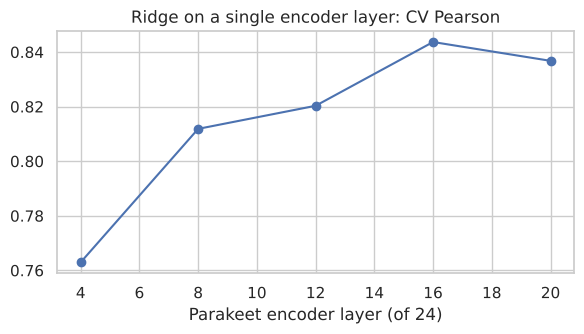

,CV RMSE,CV Pearson
layer,,
4,0.6555,0.7630
8,0.5906,0.8119
12,0.5780,0.8203
16,0.5418,0.8437
20,0.5544,0.8368


In [12]:
layer_scores = []
for k, L in enumerate(LAYERS):
    X = E["train_layers"][keep][:, k].astype(np.float32)
    o = np.zeros(len(y))
    for tr_idx, va_idx in folds:
        o[va_idx] = make_pipeline(StandardScaler(), Ridge(alpha=1000)).fit(X[tr_idx], y[tr_idx]).predict(X[va_idx])
    layer_scores.append({"layer": L, "CV RMSE": rmse(y, np.clip(o, 1, 5)), "CV Pearson": pearsonr(o, y)[0]})
layer_scores = pd.DataFrame(layer_scores).set_index("layer")
ax = layer_scores["CV Pearson"].plot(marker="o", figsize=(6, 3.5), title="Ridge on a single encoder layer: CV Pearson")
ax.set_xlabel("Parakeet encoder layer (of 24)"); plt.tight_layout(); plt.show()
layer_scores.round(4)

Early layers (4) are mostly acoustic and predict grammar poorly; layers 16–20, where the model has turned sound into words and structure, are best. Concatenating several layers is better than any single one.

## 7. Ensemble (stacking on out-of-fold predictions)

In [13]:
names = list(MODELS)
O, TE, TF = (np.column_stack([d[n] for n in names]) for d in (oof, test_pred, train_fit))
blender = LinearRegression(positive=True).fit(O, y)
print("blend weights:", {n: round(w, 3) for n, w in zip(names, blender.coef_)}, "| intercept:", round(blender.intercept_, 3))

# honest CV estimate of the blend: learn the blend weights inside each fold
oof_blend = np.zeros(len(y))
for tr_idx, va_idx in folds:
    oof_blend[va_idx] = LinearRegression(positive=True).fit(O[tr_idx], y[tr_idx]).predict(O[va_idx])
oof_blend = np.clip(oof_blend, 1, 5)
train_blend = np.clip(blender.predict(TF), 1, 5)
test_blend = np.clip(blender.predict(TE), 1, 5)

blend weights: {'Ridge | speech embedding': np.float64(0.0), 'SVR | speech embedding': np.float64(0.625), 'SVR | linguistic features': np.float64(0.029), 'Ridge | char n-gram TF-IDF': np.float64(0.096), 'Ridge | embedding + features': np.float64(0.304)} | intercept: -0.22


## 8. Results

In [14]:
table = pd.DataFrame(
    [{"model": n, "CV RMSE": rmse(y, np.clip(oof[n], 1, 5)), "CV Pearson": pearsonr(oof[n], y)[0],
      "Train RMSE": rmse(y, np.clip(train_fit[n], 1, 5)), "Train Pearson": pearsonr(train_fit[n], y)[0]} for n in names]
    + [{"model": "ENSEMBLE (final)", "CV RMSE": rmse(y, oof_blend), "CV Pearson": pearsonr(oof_blend, y)[0],
        "Train RMSE": rmse(y, train_blend), "Train Pearson": pearsonr(train_blend, y)[0]}]
).set_index("model").round(4)
display(table)
print("=" * 66)
print(f"TRAINING RMSE (final ensemble, fitted on all {len(y)} training clips): {rmse(y, train_blend):.4f}")
print(f"TRAINING Pearson                                             : {pearsonr(train_blend, y)[0]:.4f}")
print(f"5-fold CROSS-VALIDATED RMSE    (honest estimate for unseen data): {rmse(y, oof_blend):.4f}")
print(f"5-fold CROSS-VALIDATED Pearson                                  : {pearsonr(oof_blend, y)[0]:.4f}")
print(f"Baseline (always predict the mean) RMSE                         : {y.std():.4f}")
print("=" * 66)

,CV RMSE,CV Pearson,Train RMSE,Train Pearson
model,,,,
Ridge | speech embedding,0.5153,0.8595,0.3232,0.9496
SVR | speech embedding,0.5034,0.8666,0.0949,0.9963
SVR | linguistic features,0.8297,0.5769,0.5815,0.8258
Ridge | char n-gram TF-IDF,0.7624,0.6606,0.3462,0.9626
Ridge | embedding + features,0.5146,0.8598,0.3204,0.9505
ENSEMBLE (final),0.4984,0.8710,0.1559,0.9899


TRAINING RMSE (final ensemble, fitted on all 732 training clips): 0.1559
TRAINING Pearson                                             : 0.9899
5-fold CROSS-VALIDATED RMSE    (honest estimate for unseen data): 0.4984
5-fold CROSS-VALIDATED Pearson                                  : 0.8710
Baseline (always predict the mean) RMSE                         : 1.0137


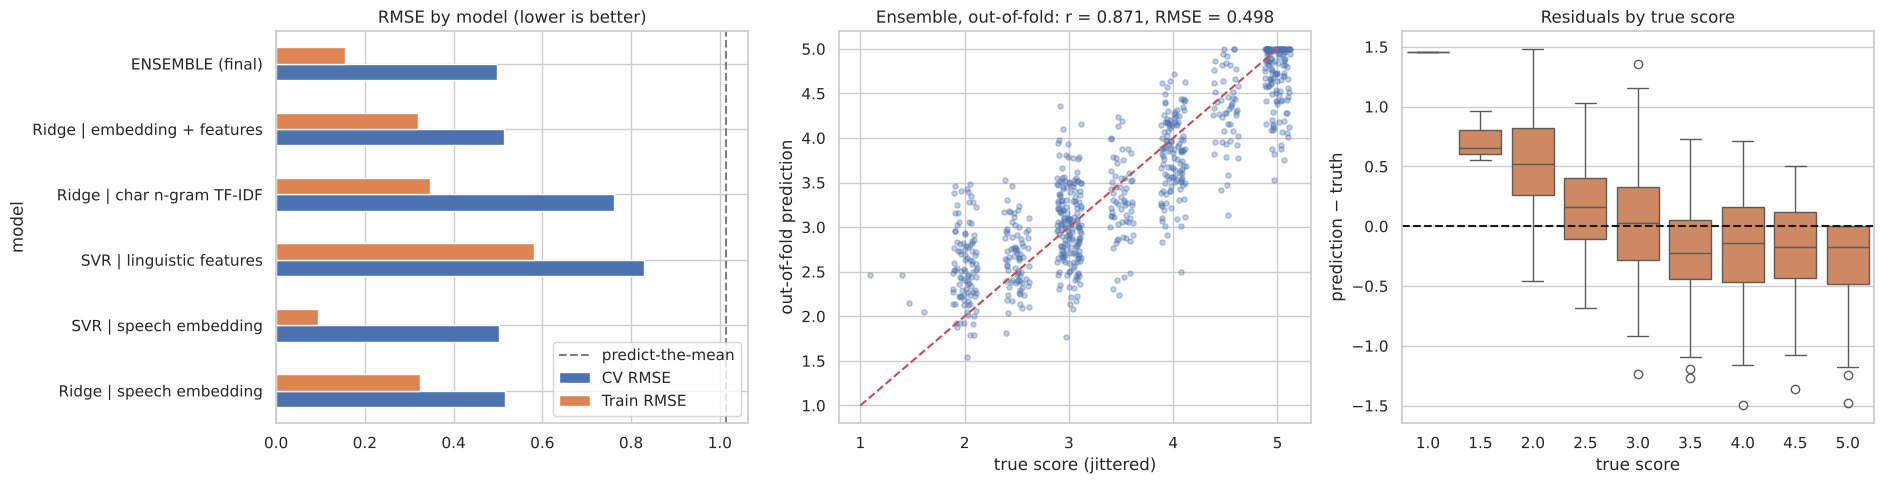

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(19, 5))
t = table.drop(columns=["Train Pearson", "CV Pearson"])
t[["CV RMSE", "Train RMSE"]].plot.barh(ax=ax[0]); ax[0].axvline(y.std(), ls="--", c="grey", label="predict-the-mean")
ax[0].set_title("RMSE by model (lower is better)"); ax[0].legend(loc="lower right")
jit = y + np.random.uniform(-0.12, 0.12, len(y))
ax[1].scatter(jit, oof_blend, alpha=0.35, s=14); ax[1].plot([1, 5], [1, 5], "r--")
ax[1].set_xlabel("true score (jittered)"); ax[1].set_ylabel("out-of-fold prediction")
ax[1].set_title(f"Ensemble, out-of-fold: r = {pearsonr(oof_blend, y)[0]:.3f}, RMSE = {rmse(y, oof_blend):.3f}")
sns.boxplot(x=y, y=oof_blend - y, ax=ax[2], color="#DD8452"); ax[2].axhline(0, c="k", ls="--")
ax[2].set_xlabel("true score"); ax[2].set_ylabel("prediction − truth"); ax[2].set_title("Residuals by true score")
plt.tight_layout(); plt.show()

**Reading the plots.** Predictions track the true scores closely (r ≈ 0.87). As with any squared-error regressor trained on few extreme examples, low scores are slightly over-predicted and 5s slightly under-predicted (regression to the mean); the largest errors are on the rare 1.0–1.5 clips.

### 8.1 Ablation: what each design decision is worth
Every row below is scored on the **same validation folds of the 732 clean clips**; only the training data or the inputs change,
so the differences are directly comparable. "With the label-0 batch" means the 37 corrupted rows are added to every training fold
(they are never used for scoring).

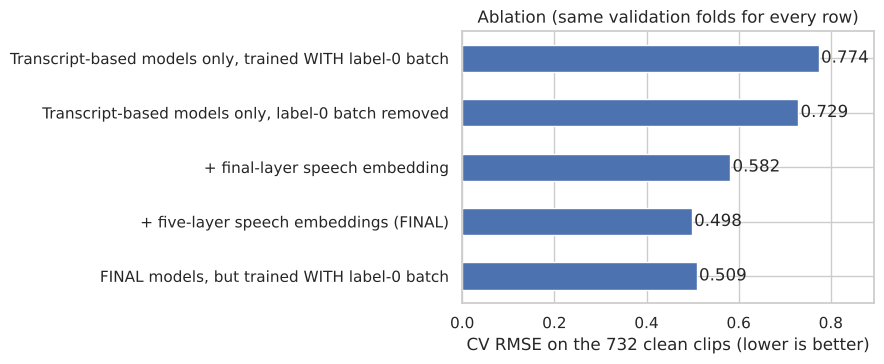

,CV RMSE,CV Pearson
step,,
"Transcript-based models only, trained WITH label-0 batch",0.7737,0.6463
"Transcript-based models only, label-0 batch removed",0.7292,0.6947
+ final-layer speech embedding,0.5816,0.8192
+ five-layer speech embeddings (FINAL),0.4984,0.8710
"FINAL models, but trained WITH label-0 batch",0.5089,0.8650


In [16]:
ci, zi = np.where(keep)[0], np.where(~keep)[0]            # clean rows / label-0 rows (indices into the full training set)
labels_all = train.label.values.astype(float)
INPUTS = {"emb5": E_train, "emb_final": E["train"].astype(np.float32), "feat": F_train_all.values,
          "text": train.text.values, "emb5+feat": np.hstack([E_train, F_train_all.values])}
BASE = {   # same model definitions as Section 6, plus a Ridge on the final-layer embedding
    "ridge_emb5": (MODELS["Ridge | speech embedding"][0], "emb5"),
    "svr_emb5": (MODELS["SVR | speech embedding"][0], "emb5"),
    "svr_feat": (MODELS["SVR | linguistic features"][0], "feat"),
    "tfidf": (MODELS["Ridge | char n-gram TF-IDF"][0], "text"),
    "ridge_emb5_feat": (MODELS["Ridge | embedding + features"][0], "emb5+feat"),
    "ridge_final_layer": (lambda: make_pipeline(StandardScaler(), Ridge(alpha=1000)), "emb_final"),
}
_cache = {}
def oof_pred(name, with_label0):
    if (name, with_label0) not in _cache:
        make, key = BASE[name]; X = INPUTS[key]; o = np.zeros(len(ci))
        for tr_idx, va_idx in folds:
            rows_ = np.concatenate([ci[tr_idx], zi]) if with_label0 else ci[tr_idx]
            o[va_idx] = make().fit(X[rows_], labels_all[rows_]).predict(X[ci[va_idx]])
        _cache[(name, with_label0)] = o
    return _cache[(name, with_label0)]
def blend_cv(names, with_label0):
    P = np.column_stack([oof_pred(n, with_label0) for n in names]); b = np.zeros(len(y))
    for tr_idx, va_idx in folds:
        b[va_idx] = LinearRegression(positive=True).fit(P[tr_idx], y[tr_idx]).predict(P[va_idx])
    b = np.clip(b, 1, 5)
    return rmse(y, b), pearsonr(b, y)[0]

TEXT = ["svr_feat", "tfidf"]
FINAL = ["ridge_emb5", "svr_emb5", "svr_feat", "tfidf", "ridge_emb5_feat"]
STEPS = [("Transcript-based models only, trained WITH label-0 batch", TEXT, True),
         ("Transcript-based models only, label-0 batch removed", TEXT, False),
         ("+ final-layer speech embedding", ["ridge_final_layer"] + TEXT, False),
         ("+ five-layer speech embeddings (FINAL)", FINAL, False),
         ("FINAL models, but trained WITH label-0 batch", FINAL, True)]
ablation = pd.DataFrame([{"step": s, "CV RMSE": r, "CV Pearson": p}
                         for s, names_, w in STEPS for r, p in [blend_cv(names_, w)]]).set_index("step").round(4)
ax = ablation["CV RMSE"][::-1].plot.barh(figsize=(9, 3.8), color="#4C72B0")
for i, v in enumerate(ablation["CV RMSE"][::-1]): ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlim(0, ablation["CV RMSE"].max() + 0.12); ax.set_xlabel("CV RMSE on the 732 clean clips (lower is better)")
ax.set_ylabel(""); ax.set_title("Ablation (same validation folds for every row)"); plt.tight_layout(); plt.show()
ablation

Removing the corrupted batch helps both the transcript-only models and the final ensemble, and the speech model's internal embeddings are by far the largest gain: they cut the error by about a third compared with transcript-based features alone.

### 8.2 Error by clip length (the test set has many more short clips)

In [17]:
short_tr = train.duration.values[keep] < 50          # ~45-second recordings
short_te = test.duration.values < 50
by_len = pd.DataFrame({
    "train clips": [short_tr.sum(), (~short_tr).sum()],
    "test clips": [short_te.sum(), (~short_te).sum()],
    "mean label (train)": [y[short_tr].mean(), y[~short_tr].mean()],
    "CV RMSE": [rmse(y[short_tr], oof_blend[short_tr]), rmse(y[~short_tr], oof_blend[~short_tr])],
    "CV Pearson": [pearsonr(oof_blend[short_tr], y[short_tr])[0], pearsonr(oof_blend[~short_tr], y[~short_tr])[0]],
}, index=["~45 s clips", "~60 s clips"]).round(3)
display(by_len)
p_short = short_te.mean()
mse_short = np.mean((oof_blend[short_tr] - y[short_tr]) ** 2)
mse_long = np.mean((oof_blend[~short_tr] - y[~short_tr]) ** 2)
print(f"{p_short:.0%} of test clips are ~45 s long (vs {short_tr.mean():.0%} of training clips).")
print(f"CV RMSE re-weighted to the test mix of clip lengths: {np.sqrt(p_short * mse_short + (1 - p_short) * mse_long):.3f}  (expected test RMSE)")

,train clips,test clips,mean label (train),CV RMSE,CV Pearson
~45 s clips,178,149,3.132,0.562,0.785
~60 s clips,554,67,3.593,0.476,0.887


69% of test clips are ~45 s long (vs 24% of training clips).
CV RMSE re-weighted to the test mix of clip lengths: 0.537  (expected test RMSE)


The ~45-second recordings are a different slice of the data (lower average score, fewer words to judge from) and are harder to score: CV RMSE ≈ 0.56 vs ≈ 0.48 on 60-second clips. Because most test clips are short, the expected test RMSE is ≈ 0.54 rather than the overall CV figure of 0.50. (Adding a learned offset for short clips to the blend improved this by only ≈ 0.006, so it was left out to keep the model simple.)

### 8.3 Speaker overlap: how well does the model work on new speakers?
Many training clips were recorded by the same people. With random K-fold, one clip of a speaker can sit in training and another in
validation, so the model can partly recognise the voice and the score looks better than it would on a new speaker.
To check, I compute a speaker embedding for every clip (WeSpeaker ResNet-34 trained on VoxCeleb, via `sherpa-onnx`),
group near-identical voices (cosine similarity > 0.8), and re-run the whole ensemble with each speaker group kept inside one fold.

training clips with a near-identical voice elsewhere in training (cos > 0.95): 65%
test clips with a near-identical voice in training (cos > 0.95):               0.5%


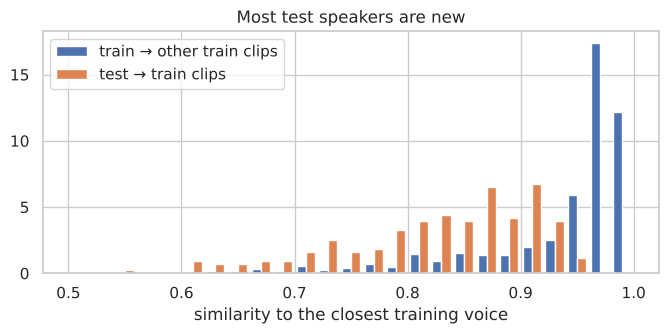

In [18]:
SPK_URL = "https://github.com/k2-fsa/sherpa-onnx/releases/download/speaker-recongition-models/wespeaker_en_voxceleb_resnet34.onnx"
spath = f"{CACHE}/spk_emb.npz"
if os.path.exists(spath):
    SPK = dict(np.load(spath))
else:                                                   # ~1 s per clip on CPU
    import sherpa_onnx
    spk_model = f"{WORK}/wespeaker_en_voxceleb_resnet34.onnx"
    if not os.path.exists(spk_model):
        subprocess.run(["curl", "-sSL", "-o", spk_model, SPK_URL], check=True)
    extractor = sherpa_onnx.SpeakerEmbeddingExtractor(
        sherpa_onnx.SpeakerEmbeddingExtractorConfig(model=spk_model, num_threads=os.cpu_count() or 4))
    SPK = {}
    for split, df in [("train", train), ("test", test)]:
        vecs = []
        for f in df.filename:
            st = extractor.create_stream(); st.accept_waveform(sample_rate=SR, waveform=load_audio(f"{DATA}/{split}/{f}"))
            st.input_finished(); vecs.append(np.array(extractor.compute(st), dtype=np.float32))
        SPK[split] = np.stack(vecs)
    np.savez_compressed(f"{WORK}/spk_emb.npz", **SPK)

unit = lambda X: X / np.linalg.norm(X, axis=1, keepdims=True)
S_tr, S_te = unit(SPK["train"])[keep], unit(SPK["test"])
C = S_tr @ S_tr.T; np.fill_diagonal(C, -1)
nearest_tr = C.max(1)                        # closest *other* training clip
nearest_te = (S_te @ S_tr.T).max(1)          # closest training clip for each test clip
print(f"training clips with a near-identical voice elsewhere in training (cos > 0.95): {np.mean(nearest_tr > 0.95):.0%}")
print(f"test clips with a near-identical voice in training (cos > 0.95):               {np.mean(nearest_te > 0.95):.1%}")
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist([nearest_tr, nearest_te], bins=np.linspace(0.5, 1, 26), density=True, label=["train → other train clips", "test → train clips"])
ax.set_xlabel("similarity to the closest training voice"); ax.legend(); ax.set_title("Most test speakers are new")
plt.tight_layout(); plt.show()

In [19]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import GroupKFold
spk_group = AgglomerativeClustering(n_clusters=None, metric="cosine", linkage="average",
                                    distance_threshold=0.2).fit(S_tr).labels_       # cosine similarity > 0.8
gfolds = list(GroupKFold(5).split(Etr, y, spk_group))

def ensemble_cv(fold_list):
    # same five models and the same blending as Sections 6-7, only the folds change
    cols = []
    for name, (make, Xtr_, _) in MODELS.items():
        o = np.zeros(len(y))
        for tr_idx, va_idx in fold_list:
            o[va_idx] = make().fit(Xtr_[tr_idx], y[tr_idx]).predict(Xtr_[va_idx])
        cols.append(o)
    P = np.column_stack(cols); b = np.zeros(len(y))
    for tr_idx, va_idx in fold_list:
        b[va_idx] = LinearRegression(positive=True).fit(P[tr_idx], y[tr_idx]).predict(P[va_idx])
    return np.clip(b, 1, 5)

oof_grouped = ensemble_cv(gfolds)
print(f"{spk_group.max() + 1} speaker groups")
print(f"random 5-fold CV         : RMSE = {rmse(y, oof_blend):.4f}   Pearson = {pearsonr(oof_blend, y)[0]:.4f}")
print(f"speaker-grouped 5-fold CV: RMSE = {rmse(y, oof_grouped):.4f}   Pearson = {pearsonr(oof_grouped, y)[0]:.4f}   <- honest estimate for new speakers")

153 speaker groups
random 5-fold CV         : RMSE = 0.4984   Pearson = 0.8710
speaker-grouped 5-fold CV: RMSE = 0.5421   Pearson = 0.8454   <- honest estimate for new speakers


On new speakers the error is ≈ 0.54 (Pearson ≈ 0.85) instead of 0.50: part of the random-fold score came from recognising voices. Since test speakers are almost all new, ≈ 0.54–0.55 is the honest expectation for the leaderboard. There is also no speaker "shortcut" to exploit on the test set. Re-tuning the models and the blend under speaker-grouped CV changed the error by less than 0.005, so the final model was kept unchanged.

## 9. Interpretability: which speech properties relate to grammar scores?

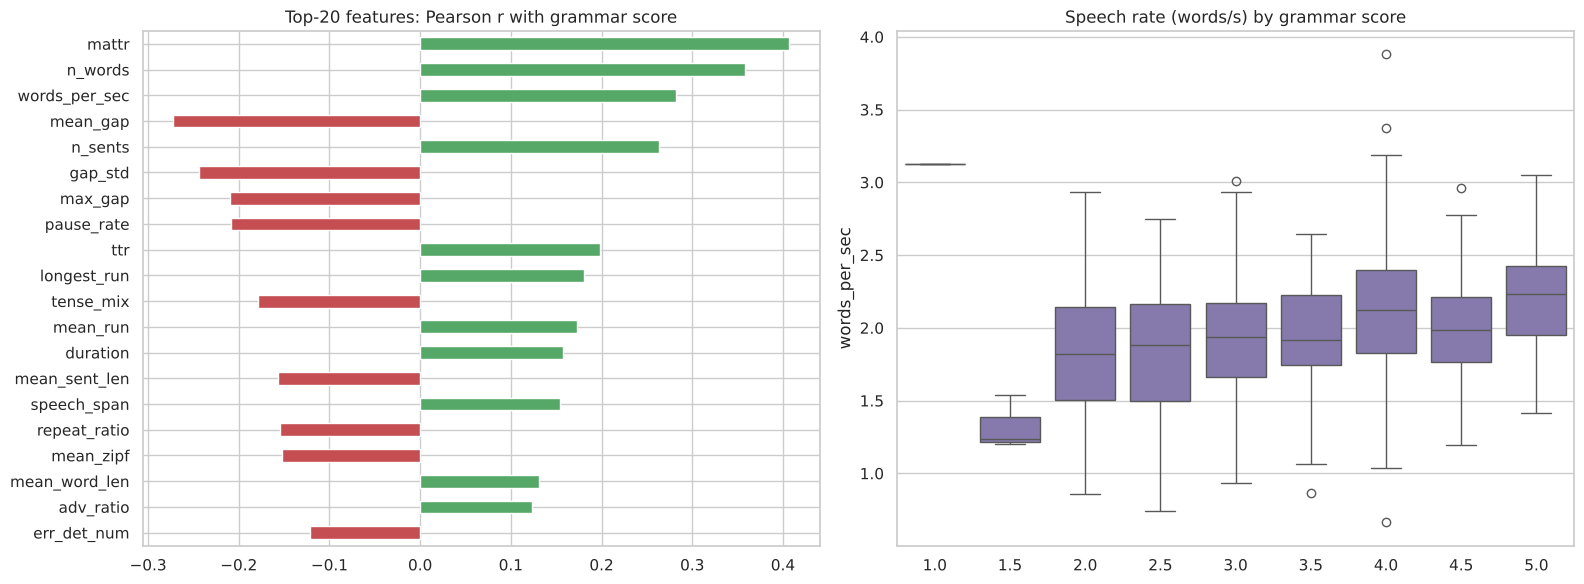

In [20]:
corr = F_train.assign(score=y).corr()["score"].drop("score")
top = corr.reindex(corr.abs().sort_values(ascending=False).index)[:20][::-1]
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
top.plot.barh(ax=ax[0], color=np.where(top > 0, "#55A868", "#C44E52")); ax[0].set_title("Top-20 features: Pearson r with grammar score")
sns.boxplot(x=y, y=F_train["words_per_sec"], ax=ax[1], color="#8172B3"); ax[1].set_title("Speech rate (words/s) by grammar score")
plt.tight_layout(); plt.show()

* Higher-scored speakers say **more words**, at a **faster, steadier rate** with fewer long pauses, use a **richer vocabulary** (higher MATTR, more varied and less common words) and produce **more, clearly bounded sentences**; lower-scored speakers produce long run-on stretches with few sentence boundaries (negative `mean_sent_len`).
* Lower-scored speakers show more **long pauses**, **repetitions** ("I I"), and **mixed tenses**.
* These features alone reach r ≈ 0.58; the speech-model embedding adds what the features miss (pronunciation, prosody and how fluently grammatical structures are produced), lifting r to ≈ 0.87.

## 10. Submission

In [21]:
submission = pd.DataFrame({"filename": test.filename, "label": test_blend})
assert len(submission) == 216 and submission.label.between(1, 5).all() and submission.filename.is_unique
submission.to_csv(f"{WORK}/submission.csv", index=False)
print(submission.label.describe().round(3))
submission.head()

count    216.000
mean       3.318
std        0.825
min        1.795
25%        2.666
50%        3.192
75%        3.824
max        5.000
Name: label, dtype: float64


,filename,label
0,audio_128.wav,2.887843
1,audio_156.wav,4.220064
2,audio_19.wav,4.400916
3,audio_108.wav,2.053309
4,audio_206.wav,2.141664


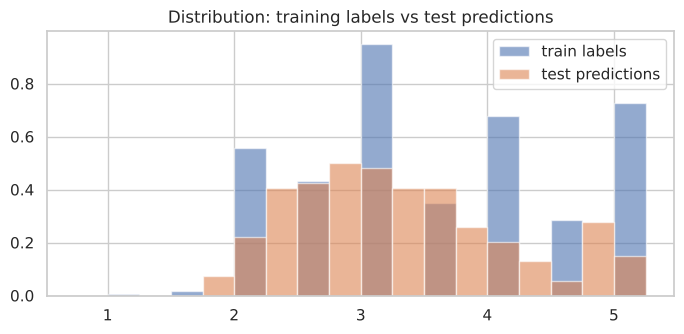

In [22]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(y, bins=np.arange(0.75, 5.5, 0.25), alpha=0.6, density=True, label="train labels")
ax.hist(test_blend, bins=np.arange(0.75, 5.5, 0.25), alpha=0.6, density=True, label="test predictions")
ax.legend(); ax.set_title("Distribution: training labels vs test predictions"); plt.tight_layout(); plt.show()

## 11. Limitations and next steps
* **ASR errors** — the transcript is an imperfect view of what was said; very disfluent speech is hardest to transcribe and to score.
* **Regression to the mean** — extreme scores (1–1.5, 5) are rarer and pulled toward the middle; ordinal or distribution-aware losses could help.
* **Label noise** — the corrupted batch shows labels are not perfectly clean; a robust loss (Huber) is a cheap safeguard.
* **New speakers** — performance drops from RMSE 0.50 to 0.54 on unseen voices; speaker-grouped CV should be used for any further model selection.
* **Next steps:** learn the layer weighting / pooling instead of plain averaging, fine-tune a text transformer on the transcripts, and add a grammar-error-correction model to count edits per word.